In [4]:
#Goal:
#Convert raw numerical values into meaningful context for the Decision Agent.
import pandas as pd
df=pd.read_excel("../data/cleandata.xlsx")
df.head()
#Did I load the dataset correctly?

,date,Power Consumption,Outdoor Temperature,Occupancy
0,2018-05-22 00:00:00,71.98,15.72,1
1,2018-05-22 00:15:00,71.00,15.37,1
2,2018-05-22 00:30:00,65.20,15.27,0
3,2018-05-22 00:45:00,95.90,16.03,0
4,2018-05-22 01:00:00,43.60,15.28,0


In [6]:
cols=["Power Consumption","Outdoor Temperature","Occupancy"]
for col in cols:
    print(col)
    print("min:",df[col].min())
    print("max:",df[col].max())
    print("mean:",df[col].mean())

Power Consumption
min: 4.59
max: 180.38
mean: 71.50253930942827
Outdoor Temperature
min: 5.87
max: 29.61
mean: 14.67309237136676
Occupancy
min: 0
max: 122
mean: 11.741510676323959


In [7]:
cols=["Power Consumption","Outdoor Temperature","Occupancy"]
print(df[cols].quantile([0.25,0.5,0.75]))

      Power Consumption  Outdoor Temperature  Occupancy
0.25          57.090000                11.88        0.0
0.50          69.000000                13.83        2.0
0.75          83.289471                17.20       15.0


Axes(0.125,0.11;0.775x0.77)


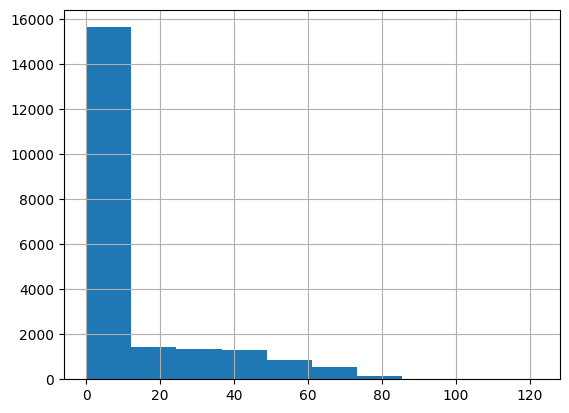

In [8]:
print(df.Occupancy.hist())

In [9]:
def power_category(power):
    if power < 60:
        return "Low power"

    elif power <= 100:
        return "Medium power"

    else:
        return "High power"
def temp_category(temp):
    if temp<12:
        return"Cool temperature"
    elif temp<= 18:
        return "Moderate temperature"
    else:
        return "Hot temperature"
def occupancy_status(occ):
    if occ==0:
        return "No occupancy"
    elif 1<=occ<=5:
        return "Low occupancy"
    elif 6<=occ<=20:
        return "Medium occupancy"
    else:
        return "High occupancy"
    
def extract_hour(hour):
    if 0<=hour<=3:
        return "Late Night"
    elif 4<=hour<=6:
        return "Early Morning"
    elif 7<=hour<=11:
        return "Morning"
    elif 12<=hour<=15:
        return "Afternoon"
    elif 16<=hour<=19:
        return "Evening"
    else:
        return "Night"
    

In [10]:
print(power_category(120))
print(temp_category(20))
print(occupancy_status(1))
print(extract_hour(18))

High power
Hot temperature
Low occupancy
Evening


In [11]:
df["date"] = pd.to_datetime(df["date"])          # ensure datetime type
df["Time of Day"] = df["date"].dt.hour.apply(extract_hour)

df["Power Category"] = df["Power Consumption"].apply(power_category)
df["Temperature Category"] = df["Outdoor Temperature"].apply(temp_category)
df["Occupancy Status"] = df["Occupancy"].apply(occupancy_status)

df.head()

,date,Power Consumption,Outdoor Temperature,Occupancy,Time of Day,Power Category,Temperature Category,Occupancy Status
0,2018-05-22 00:00:00,71.98,15.72,1,Late Night,Medium power,Moderate temperature,Low occupancy
1,2018-05-22 00:15:00,71.00,15.37,1,Late Night,Medium power,Moderate temperature,Low occupancy
2,2018-05-22 00:30:00,65.20,15.27,0,Late Night,Medium power,Moderate temperature,No occupancy
3,2018-05-22 00:45:00,95.90,16.03,0,Late Night,Medium power,Moderate temperature,No occupancy
4,2018-05-22 01:00:00,43.60,15.28,0,Late Night,Low power,Moderate temperature,No occupancy


In [12]:
import sys

print(sys.executable)

c:\Users\HP\AppData\Local\Programs\Python\Python312\python.exe


In [15]:
df["Hour"] = df["date"].dt.hour
df[["date","Hour"]].head()

,date,Hour
0,2018-05-22 00:00:00,0
1,2018-05-22 00:15:00,0
2,2018-05-22 00:30:00,0
3,2018-05-22 00:45:00,0
4,2018-05-22 01:00:00,1


In [17]:
hourly_power_memory = (
    df.groupby("Hour")
      ["Power Consumption"]
      .mean()
)

hourly_power_memory

Hour
0     79.486374
1     71.802297
2     68.242958
3     64.822755
4     62.171010
5     62.688729
6     60.550273
7     60.091039
8     60.270635
9     60.005732
10    60.548643
11    60.840583
12    60.243475
13    65.803466
14    70.901557
15    75.743234
16    78.868223
17    81.781956
18    84.083768
19    85.569857
20    86.581522
21    87.089294
22    85.350235
23    85.111979
Name: Power Consumption, dtype: float64

In [19]:
hourly_occupancy_memory = (
    df.groupby("Hour")
      ["Occupancy"]
      .mean()
)

hourly_occupancy_memory

Hour
0      2.543182
1      2.655251
2      3.777523
3      6.755734
4     10.419725
5     11.859709
6     17.764908
7     20.251147
8     20.214450
9     22.764908
10    22.705275
11    19.916284
12    16.376147
13    15.564719
14    13.581236
15    11.777523
16    10.566514
17    10.464450
18    10.268349
19     9.962243
20     8.284404
21     5.823394
22     4.406818
23     3.356335
Name: Occupancy, dtype: float64

In [21]:
hourly_temperature_memory = (
    df.groupby("Hour")
      ["Outdoor Temperature"]
      .mean()
)

hourly_temperature_memory

Hour
0     16.000375
1     15.461455
2     14.804484
3     14.240833
4     13.803560
5     12.545552
6     13.306950
7     13.043911
8     12.898349
9     13.000103
10    13.317431
11    13.626583
12    13.962087
13    14.245132
14    14.521367
15    14.938503
16    15.513119
17    16.020539
18    16.181779
19    16.269856
20    16.208039
21    16.278647
22    16.373673
23    16.260462
Name: Outdoor Temperature, dtype: float64

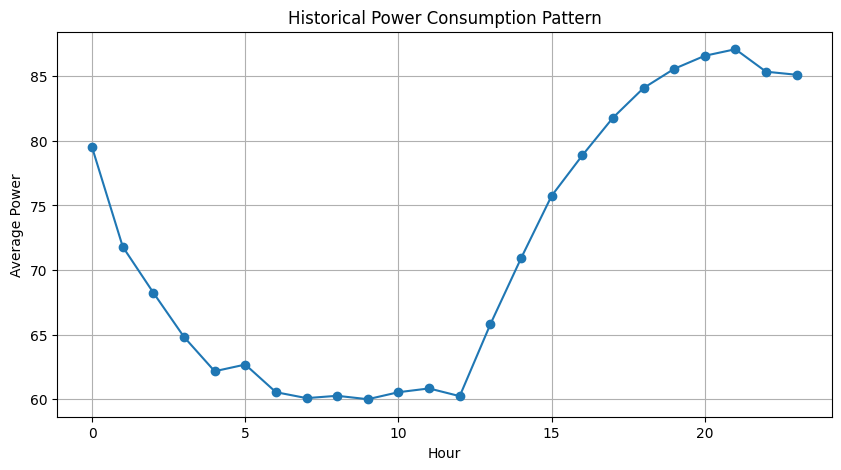

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

hourly_power_memory.plot(marker="o")

plt.title("Historical Power Consumption Pattern")
plt.xlabel("Hour")
plt.ylabel("Average Power")

plt.grid(True)

plt.show()

In [25]:
def get_historical_context(hour):

    expected_power = hourly_power_memory[hour]

    expected_occ = hourly_occupancy_memory[hour]

    expected_temp = hourly_temperature_memory[hour]

    return {
        "expected_power": round(expected_power,2),
        "expected_occupancy": round(expected_occ,2),
        "expected_temperature": round(expected_temp,2)
    }

In [27]:
get_historical_context(2)

{'expected_power': np.float64(68.24),
 'expected_occupancy': np.float64(3.78),
 'expected_temperature': np.float64(14.8)}

In [29]:
{
 'expected_power': 58.2,
 'expected_occupancy': 0.3,
 'expected_temperature': 13.1
}

{'expected_power': 58.2,
 'expected_occupancy': 0.3,
 'expected_temperature': 13.1}

In [31]:
sample = df.iloc[0]

hour = sample["Hour"]

memory = get_historical_context(hour)

print(memory)

{'expected_power': np.float64(79.49), 'expected_occupancy': np.float64(2.54), 'expected_temperature': np.float64(16.0)}


In [33]:
current_power = sample["Power Consumption"]

historical_power = memory["expected_power"]

deviation = current_power - historical_power

print(deviation)

-7.5100003619999995


In [34]:
print(get_historical_context(2))

{'expected_power': np.float64(68.24), 'expected_occupancy': np.float64(3.78), 'expected_temperature': np.float64(14.8)}
